In [108]:
import os
from dotenv import load_dotenv
load_dotenv(dotenv_path=r"C:\E drive\A.I Classes\Agentic and Gen AI with Cloud\.env")
os.environ['GROQ_API_KEY']=os.getenv("GROQ_API_KEY")

In [109]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="openai/gpt-oss-20b")
result=llm.invoke("hey")
print(result.content)

Hey there! 👋 How can I help you today?


In [110]:
from langgraph.graph import START, END, StateGraph, MessagesState
from typing_extensions import TypedDict
from langchain_core.messages import AIMessage, SystemMessage, HumanMessage
from pydantic import BaseModel
from IPython.display import display, Image

In [111]:
class blog(TypedDict):
    topic:str
    blogs:str
    headline:str
    agg:str
    

In [112]:



def generator_content(state:blog):
    '''
    Generate the content of the human input topic
    '''
    message=llm.invoke(f"You are blog writer expert. You are writing for complete beginners with no prior background on {state["topic"]}. Your tone should be formal, clear, educational — explicitly say explain like teaching a first-time learner, but don't be condescending.")

    return {"blogs":message.content}
    
    
def headline(state:blog):
    '''
    Generate 5 headline options that are clear, formal, and describe exactly what a beginner will learn. Avoid clickbait, avoid vague titles.
    '''
    message=llm.invoke(f"Generate 5 headline {state["topic"]} options that are clear, formal, and describe exactly what a beginner will learn. Avoid clickbait, avoid vague titles.")
    
    return {"headline":message.content}
    
    


def aggerator(state:blog):
    '''
    Summarize headline, content and example and giving out the sturtuceted output
    '''
    
    message=llm.invoke(f"you are expert of aggerating the content for blog like {state["headline"]}, {state["blogs"]}, example.. and giving it into very good and presetable and sturcutred way")
    
    return {"agg":message.content}


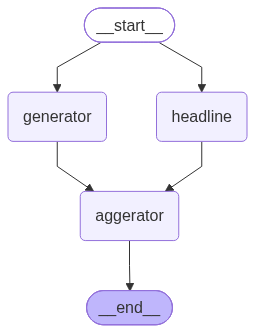

In [113]:
graph=StateGraph(blog)
graph.add_node("generator",generator_content)
graph.add_node("headline",headline)
graph.add_node("aggerator",aggerator)


graph.add_edge(START,"generator")
graph.add_edge(START,"headline")
graph.add_edge("headline","aggerator")
graph.add_edge("generator","aggerator")
graph.add_edge("aggerator",END)

graph=graph.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [114]:
graph.invoke({"topic":"India"})

{'topic': 'India',
 'blogs': '# India for the First‑Time Learner  \n*A clear, formal introduction for those who have never studied the country before*\n\n---\n\n## 1.  What Is India?\n\nIndia is a sovereign nation located in South Asia. It is the **seventh largest country in the world by area** and the **second most populous** (after China). India is a federal republic, meaning that power is shared between the national government and the individual states.\n\n> **Key point** – *India is both a land and a people; its diversity is part of its identity.*\n\n---\n\n## 2.  Geography: Where Does It Sit?\n\n| Feature | Description |\n|---------|-------------|\n| **Borders** | 2,933 km (1,825 mi) of land borders: Pakistan (to the west), China, Nepal, Bhutan, and Bangladesh. It also shares maritime borders with Sri Lanka, the Maldives, and the Arabian Sea. |\n| **Rivers** | The Ganges, Brahmaputra, Indus, and Yamuna are the most important. They shape agriculture, culture, and settlement pattern